# Importing libraries 

In [98]:
%pip install scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# ---------------------------------------------------------------------------------------------------------------

In [99]:
df = pd.read_csv("../data/raw/car_data.csv")

In [100]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [101]:
# Deleting unused columns 
df = df.drop("Transmission", axis=1) 
df = df.drop("Engine", axis=1)

In [102]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,Red,24500,53546-9427,Hatchback,7081483,Janesville


# ---------------------------------------------------------------------------------------------------------------
# No Null Values detected

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Color          23906 non-null  object
 9   Price ($)      23906 non-null  int64 
 10  Dealer_No      23906 non-null  object
 11  Body Style     23906 non-null  object
 12  Phone          23906 non-null  int64 
 13  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(11)
memory usage: 2.6+ MB


# duplicated Values

In [104]:
df.duplicated("Phone").sum() # doublicated detected if their was we where go use dropdublicated()

102

In [105]:
df[df.duplicated("Phone")]


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
2288,C_CND_002289,5/7/2022,Sariah,Female,1650000,Saab-Belle Dodge,Ford,Windstar,Pale White,19000,60504-7114,Sedan,8138829,Aurora
2608,C_CND_002609,5/23/2022,Janice,Male,2268000,Rabun Used Car Sales,Toyota,Celica,Pale White,45800,85257-3102,SUV,7410063,Pasco
2697,C_CND_002698,5/26/2022,Katherine,Male,13500,Tri-State Mack Inc,Mitsubishi,3000GT,Red,24000,85257-3102,Sedan,7298842,Austin
2814,C_CND_002815,5/31/2022,Benjamin,Male,1381500,Hatfield Volkswagen,Plymouth,Voyager,Red,20150,99301-3882,Passenger,6015528,Pasco
3350,C_CND_003351,6/19/2022,Enrique,Male,545000,Motor Vehicle Branch Office,Buick,Park Avenue,Black,29000,78758-7841,Hatchback,8389695,Austin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23089,C_CND_023090,12/16/2023,Veronica,Male,13500,New Castle Ford Lincoln Mercury,Mitsubishi,Eclipse,Black,25000,60504-7114,Hardtop,7150746,Greenville
23169,C_CND_023170,12/18/2023,Claire,Male,13500,Suburban Ford,Acura,RL,Red,31001,53546-9427,SUV,6461849,Janesville
23312,C_CND_023313,12/22/2023,Hailey,Male,755000,New Castle Ford Lincoln Mercury,Dodge,Ram Van,Red,31000,60504-7114,Hatchback,8535490,Aurora
23352,C_CND_023353,12/23/2023,August,Male,555000,Saab-Belle Dodge,BMW,528i,Black,31000,60504-7114,SUV,7171469,Aurora


In [106]:
df= df.drop_duplicates(subset="Phone",  keep=False)

In [107]:
df.duplicated("Phone").sum() # all dublicated values are removed

0

# ---------------------------------------------------------------------------------------------------------------
# outliers


### Before handing the outliers

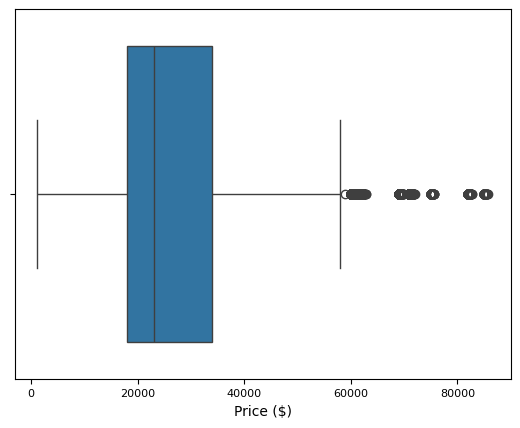

In [108]:
sns.boxplot(x="Price ($)", data=df)
plt.show()

In [109]:
# let's detect outliers:
Q1 = df["Price ($)"].quantile(0.25)
print('Q1: ',Q1)
Q3 = df["Price ($)"].quantile(0.75)
print('Q3: ',Q3)
IQR = Q3 - Q1
print('IQR: ',IQR)

lower_bound = (1.5 * IQR) - Q1
print('lower_bound: ',lower_bound)
upper_bound = Q3 +(1.5 * IQR)
print('upper_bound: ',upper_bound)


Q1:  18001.0
Q3:  34000.0
IQR:  15999.0
lower_bound:  5997.5
upper_bound:  57998.5


In [110]:
filter_lower_bound = (df["Price ($)"] < lower_bound)
filter_upper_bound = (df["Price ($)"] > upper_bound)
# to see outliers
print(df["Price ($)"][(filter_lower_bound | filter_upper_bound)])

8        82000
37       61000
65       61000
73       62000
108      71000
         ...  
23839    75000
23846    71000
23881    69001
23895    61000
23899    62000
Name: Price ($), Length: 1445, dtype: int64


In [111]:
df["Price ($)"]=np.where(df["Price ($)"]>upper_bound,upper_bound,np.where(df["Price ($)"]<lower_bound,lower_bound,df["Price ($)"]))

### After Handing it

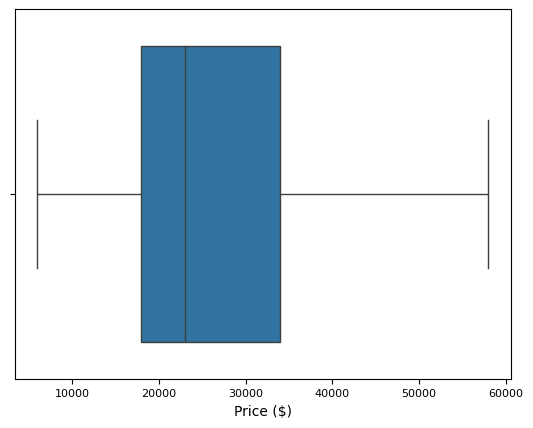

In [112]:
sns.boxplot(x="Price ($)", data=df)
plt.show()

 ### To check the mean

In [113]:
df["Price ($)"].mean()

27427.45086912497

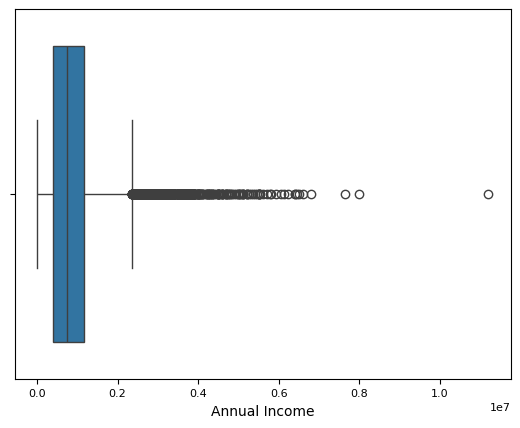

In [114]:
sns.boxplot(x="Annual Income", data=df)
plt.show()

In [115]:
# let's detect outliers:
A1 = df["Annual Income"].quantile(0.25)
print('A1: ',A1)
A3 = df["Annual Income"].quantile(0.75)
print('A3: ',A3)
IAR = A3 - A1
print('IAR: ',IAR)

lower_bound1 = (1.5 * IAR) - A1
print('lower_bound1: ',lower_bound1)
upper_bound1 = A3 + (1.5 * IAR)
print('upper_bound1: ',upper_bound1)

A1:  387625.0
A3:  1175000.0
IAR:  787375.0
lower_bound1:  793437.5
upper_bound1:  2356062.5


In [116]:
filter_lower_bound1 = (df["Annual Income"] > lower_bound1)
filter_upper_bound1 = (df["Annual Income"] < upper_bound1)
# to see outliers
print(df["Annual Income"][(filter_lower_bound1 | filter_upper_bound1)])

0          13500
1        1480000
2        1035000
3          13500
4        1465000
          ...   
23901      13500
23902     900000
23903     705000
23904      13500
23905    1225000
Name: Annual Income, Length: 23702, dtype: int64


In [117]:
df["Annual Income"]=np.where(df["Annual Income"]>upper_bound1,upper_bound1,np.where(df["Annual Income"]<lower_bound1,lower_bound1,df["Annual Income"]))

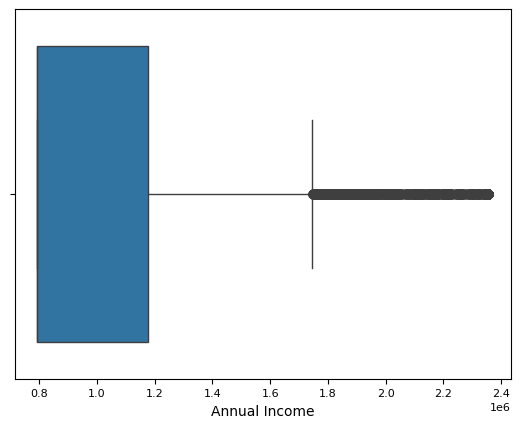

In [118]:
sns.boxplot(x="Annual Income", data=df)
plt.show()

In [119]:
df['Annual Income'].mean()

1044680.745717661

In [120]:
df.groupby("Color").Color.count() # No outliers detected in Color

Color
Black          7787
Pale White    11156
Red            4759
Name: Color, dtype: int64

In [121]:
df.groupby("Company").Company.count() # No outliers detected in Company

Company
Acura          684
Audi           466
BMW            781
Buick          437
Cadillac       649
Chevrolet     1805
Chrysler      1112
Dodge         1658
Ford          1599
Honda          701
Hyundai        260
Infiniti       194
Jaguar         176
Jeep           359
Lexus          793
Lincoln        489
Mercedes-B    1272
Mercury        869
Mitsubishi    1262
Nissan         880
Oldsmobile    1105
Plymouth       611
Pontiac        788
Porsche        359
Saab           207
Saturn         581
Subaru         403
Toyota        1100
Volkswagen    1321
Volvo          781
Name: Company, dtype: int64

In [122]:
df.groupby("Gender").Gender.count() # No outliers detected in Gender

Gender
Female     5058
Male      18644
Name: Gender, dtype: int64

In [123]:
df.groupby("Model").Model.count() # No outliers detected in Model

Model
3-Sep       169
3000GT      298
300M        243
323i        260
328i        202
           ... 
Viper       236
Voyager     179
Windstar    118
Wrangler    162
Xterra       92
Name: Model, Length: 154, dtype: int64

In [124]:
df.groupby("Dealer_Region").Dealer_Region.count() # No outliers detected in Dealer_Region

Dealer_Region
Aurora        3100
Austin        4104
Greenville    3108
Janesville    3780
Middletown    3101
Pasco         3107
Scottsdale    3402
Name: Dealer_Region, dtype: int64

### Shape of the data after dropping outliers and duplicates

In [125]:
print("Shape of the data after dropping outliers and duplicates:", df.shape)
df.info()

Shape of the data after dropping outliers and duplicates: (23702, 14)
<class 'pandas.core.frame.DataFrame'>
Index: 23702 entries, 0 to 23905
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_id         23702 non-null  object 
 1   Date           23702 non-null  object 
 2   Customer Name  23701 non-null  object 
 3   Gender         23702 non-null  object 
 4   Annual Income  23702 non-null  float64
 5   Dealer_Name    23702 non-null  object 
 6   Company        23702 non-null  object 
 7   Model          23702 non-null  object 
 8   Color          23702 non-null  object 
 9   Price ($)      23702 non-null  float64
 10  Dealer_No      23702 non-null  object 
 11  Body Style     23702 non-null  object 
 12  Phone          23702 non-null  int64  
 13  Dealer_Region  23702 non-null  object 
dtypes: float64(2), int64(1), object(11)
memory usage: 2.7+ MB


# ---------------------------------------------------------------------------------------------------------------

### Aggregation and Encoding


## In this code cell, we are performing two main operations: aggregation and encoding.
### - Aggregation is performed to calculate the mean of 'Price' and the sum of 'Annual Income' for each combination of 'Color' and 'Company' using groupby() and agg() functions. Then the reset_index() function is used yo reset the index of the dataframe.

### - Encoding is performed to convert categorical variables into numerical representations using one-hot encoding. This is done for the 'Color' and 'Company' columns in the aggregated DataFrame using pd.get_dummies() function. This function creates new columns for each unique value in the specified columns and assigns a binary value (0 or 1) to indicate the presence or absence of that value in each row

In [126]:
# Aggregation
df_agg = df.groupby(['Color', 'Company']).agg({'Price ($)': 'mean', 'Annual Income': 'sum'}).reset_index()

# Print the aggregated DataFrame
print(df_agg)

# Encoding
df_encoded = pd.get_dummies(df_agg, columns=['Color', 'Company'])

# Print the encoded DataFrame
print(df_encoded)


    Color     Company     Price ($)  Annual Income
0   Black       Acura  26909.147887    287024425.0
1   Black        Audi  25275.305118    260605062.5
2   Black         BMW  23223.815315    354393875.0
3   Black       Buick  25749.805085    189577250.0
4   Black    Cadillac  39565.951389    322875687.5
..    ...         ...           ...            ...
85    Red      Saturn  35802.170543    141990750.0
86    Red      Subaru  34647.398374    119262437.5
87    Red      Toyota  29309.473529    179030874.0
88    Red  Volkswagen  28537.792264    363499687.5
89    Red       Volvo  26097.137795    136642250.0

[90 rows x 4 columns]
       Price ($)  Annual Income  Color_Black  Color_Pale White  Color_Red  \
0   26909.147887    287024425.0         True             False      False   
1   25275.305118    260605062.5         True             False      False   
2   23223.815315    354393875.0         True             False      False   
3   25749.805085    189577250.0         True             

## General Visualizations

### Time Series Analysis: Monthly Car Sales
highlighting seasonal patterns

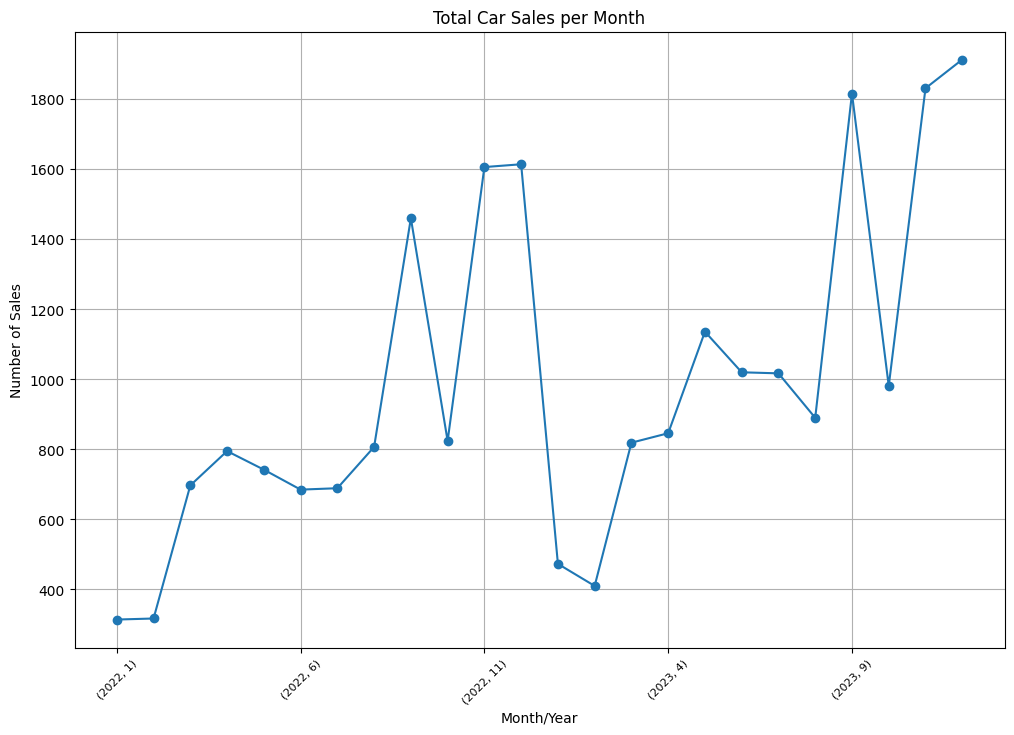

In [127]:
# Convert 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and year from the 'Date' column
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Group the data by month and year
monthly_sales = df.groupby(['Year', 'Month']).size()

# Time Series Analysis: Total Car Sales per Month
plt.figure(figsize=(12, 8))
monthly_sales.plot(marker='o')
plt.title('Total Car Sales per Month')
plt.xlabel('Month/Year')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Geospatial Analysis (Total Car Sales by Region)
providing insights into geographical preferences

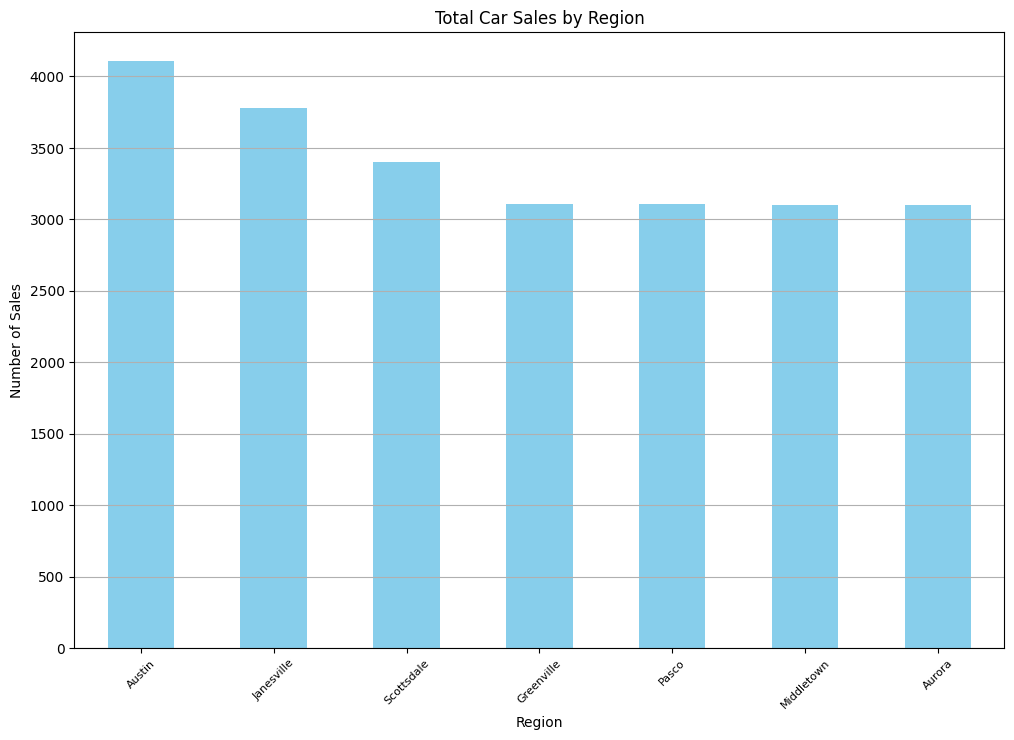

In [128]:
plt.figure(figsize=(12, 8))
total_sales_by_region = df['Dealer_Region'].value_counts()
total_sales_by_region.plot(kind='bar', color='skyblue')
plt.title('Total Car Sales by Region')
plt.xlabel('Region')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
# 1 - Does every region have a preference for Body Style of cars, and the region with the most selling cars?

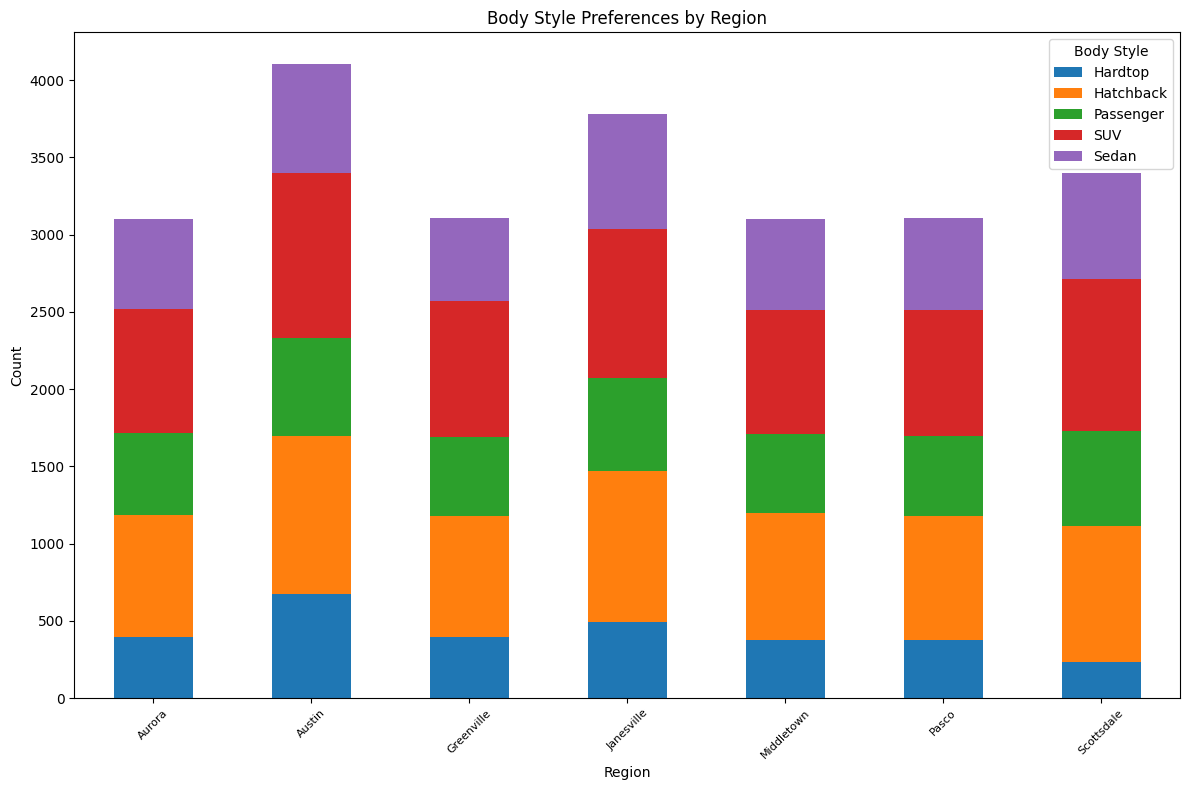

In [129]:
region_body_style = df.groupby(['Dealer_Region', 'Body Style']).size().unstack()

region_body_style.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.title('Body Style Preferences by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Body Style')
plt.tight_layout()
plt.show()

## -As we can see from the graph Austin has the most selling cars.
## -And most of the region are nearly equal in the quantity of selling cars.

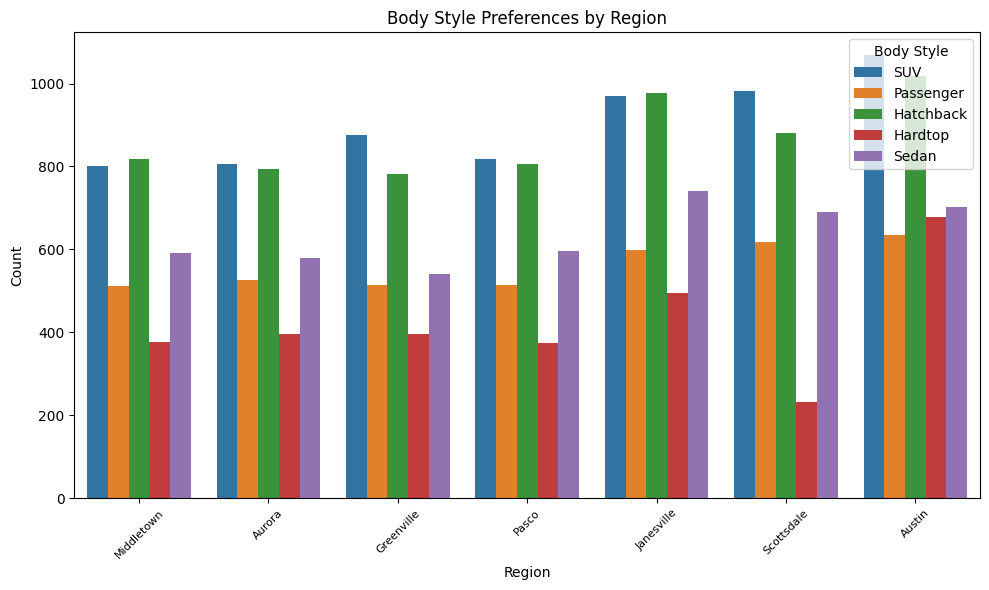

In [130]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Dealer_Region', hue='Body Style', data=df) # plot type = scountplot
plt.title('Body Style Preferences by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Body Style')
plt.tight_layout()
plt.show()


## - The results shows that every region have diffrent preferences in body style
### as the reuslt shows SUV and Hatchback are the most selling Cars in all the region and it differs from one region to another

## - Austin has the most selling cars
### in all body styles catagories Austin is greater than other regions

## - Hardtop is the least selling cars in all regions except in Austine

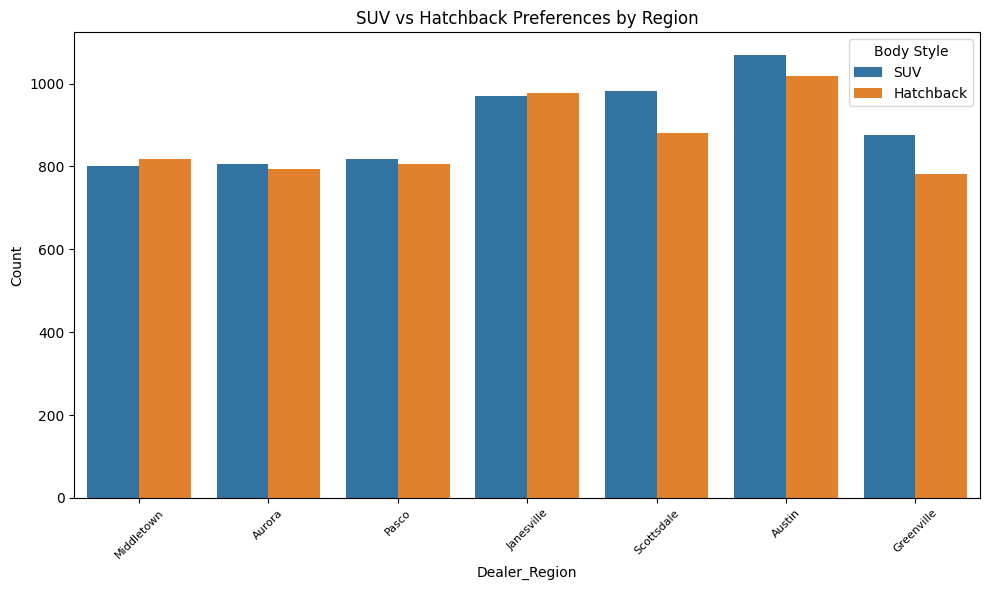

In [131]:
filtered_df = df[df['Body Style'].isin(['SUV', 'Hatchback'])]

plt.figure(figsize=(10, 6))
sns.countplot(x='Dealer_Region', hue='Body Style', data=filtered_df)
plt.title('SUV vs Hatchback Preferences by Region')
plt.xlabel('Dealer_Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Body Style')
plt.tight_layout()
plt.show()

# regions will need to produce more SUV & Hatchback cars

## - SUV is the most selling cars in (Austin, Scottsdale, Greenville, Pasco, Aurora)

## - Hatchback is the most selling cars in (Middletown, Janesville)

## these regions will not need to produce alot alot of hardtop cars & passenger.

# In conclusion, our analysis reveals that each region exhibits distinct preferences for body styles, providing valuable insights into which specific body styles to prioritize and which ones to minimize in each region. This understanding allows us to tailor our strategies to effectively focus to regional preferences, focusing our efforts on promoting favored body styles while reducing less popular ones.

# ---------------------------------------------------------------------------------------------------------------

# 3 - How does customer gender influence car purchasing behavior, including preferences for company, color, and overall frequency of purchases?

### Calculate the total number of cars purchased by each gender


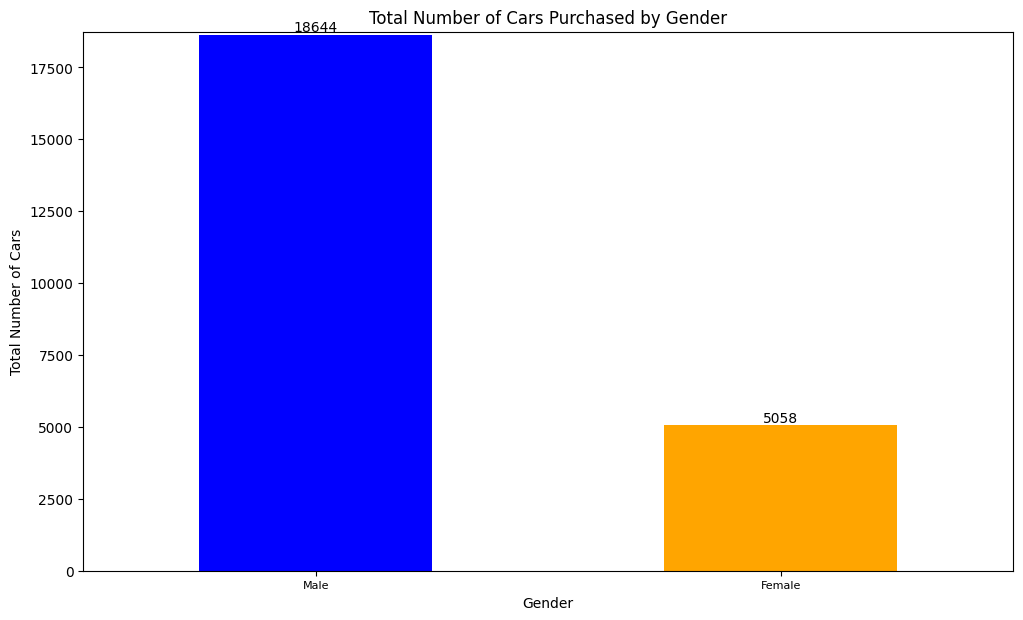

In [132]:
total_cars_by_gender = df['Gender'].value_counts()

#  the total number of cars purchased by gender
plt.figure(figsize=(12, 7))
ax = total_cars_by_gender.plot(kind='bar', color=['blue', 'orange'])
plt.title('Total Number of Cars Purchased by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Number of Cars')
plt.xticks(rotation=0)
plt.ylim(0, max(total_cars_by_gender) + 100)
for i, count in enumerate(total_cars_by_gender):
    plt.text(i, count + 5, str(count), ha='center', va='bottom')
plt.show()


In [133]:
avg_cars_by_gender = total_cars_by_gender.mean()

print("Average number of cars purchased by each gender:", avg_cars_by_gender)

Average number of cars purchased by each gender: 11851.0


### - As we see that the male buy 75% more than female
### -The Avg number of car purchase by each gender is = 11851

## Group the data by customer gender and body company


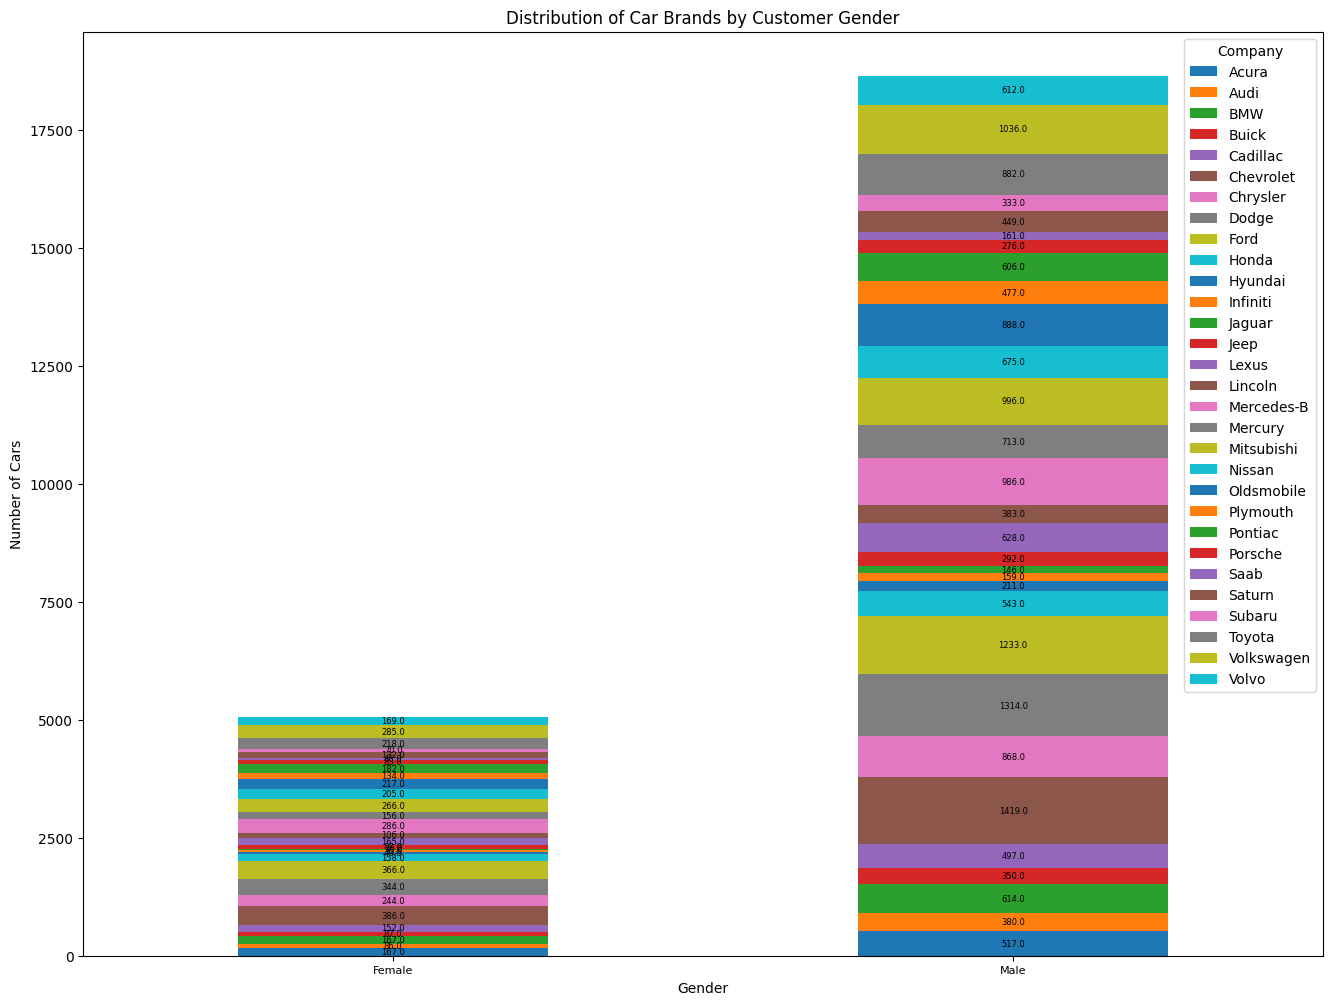

In [134]:
# Group the data by customer gender and car brand
gender_brand = df.groupby(['Gender', 'Company']).size().unstack()

# the distribution of car brands by gender
ax = gender_brand.plot(kind='bar', stacked=True, figsize=(16, 12))

# Set the title and labels
plt.title('Distribution of Car Brands by Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Cars')

# Rotate the x-axis labels
plt.xticks(rotation=0)

# Place the legend inside the plot
plt.legend(title='Company', loc='upper right')

# Add text inside each bar (These numbers inside each segment indicate the count of cars of that particular brand for the corresponding gender.)
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy() 
    ax.annotate(f'{height}', (x + width/2, y + height/2), ha='center', va='center', fontsize=6)  
    # Adjusted fontsize so it can be readable

plt.show()


## From the graph above we anlyze That: 
### - male prefer to buy (Toyota,Volkswagen)
### - Female prefer to buy (Saturn,Mercedes-B)   
### - The most unsell car to the male is (Pontiac,Saab )
### - The female unsell car to the male is (Chrysler,Lexus)
### - The most common car sales between male and female is (Mercedes-B)

### Group the data by customer gender and car color

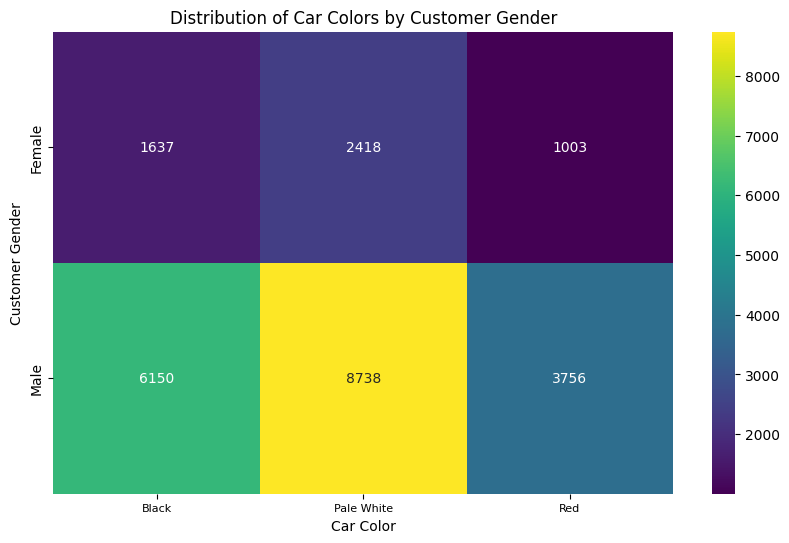

In [135]:
gender_color = df.groupby(['Gender', 'Color']).size().unstack()

# the distribution of car colors by gender as a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(gender_color, cmap='viridis', annot=True, fmt='d')
plt.title('Distribution of Car Colors by Customer Gender')
plt.xlabel('Car Color')
plt.ylabel('Customer Gender')
plt.show()

## From the graph above we anlyze That:

### - The most car male buys it is the (pale white)cars
### - The most car female  buys it is the (pale white) cars
### - From this result we analyse  that the pale white is the most colour two both male and female to buy
### - The most unsell color to male is (Red)
### - The most unsell color to female is (Red)
### - From the data we gather we know that the red is the most unsell colour for male and female

## - In the conclusion we analyse the the dealers need to buy Toyota, Volkswagen, Saturn, Mercedes-B more than Pontiac, Saab Chrysler, Lexus also buy white cars more than red cars

# ---------------------------------------------------------------------------------------------------------------

# 4 - How different factors influence customer behavior and buying habits preferences?
### Goals: Trying to understand how factors like gender and annual income connect with the customer’s buying decisions including model, color, and body style of the car.
## Hints: 
### Group the data by customer gender then analyze to explore the relationships between the gender and car brands, models, colors, and body styles. 
### Use statistics to compare average annual income across different car brands, models, colors, and body styles.

Relationship between gender and car brands:
Gender  Company   
Female  Chevrolet      386
        Ford           366
        Dodge          344
        Mercedes-B     286
        Volkswagen     285
        Mitsubishi     266
        Chrysler       244
        Toyota         218
        Oldsmobile     217
        Nissan         205
        Pontiac        182
        Volvo          169
        Acura          167
        BMW            167
        Lexus          165
        Honda          158
        Mercury        156
        Cadillac       152
        Plymouth       134
        Saturn         132
        Lincoln        106
        Buick           87
        Audi            86
        Porsche         83
        Subaru          70
        Jeep            67
        Hyundai         49
        Saab            46
        Infiniti        35
        Jaguar          30
Male    Chevrolet     1419
        Dodge         1314
        Ford          1233
        Volkswagen    1036
        Mitsubishi 

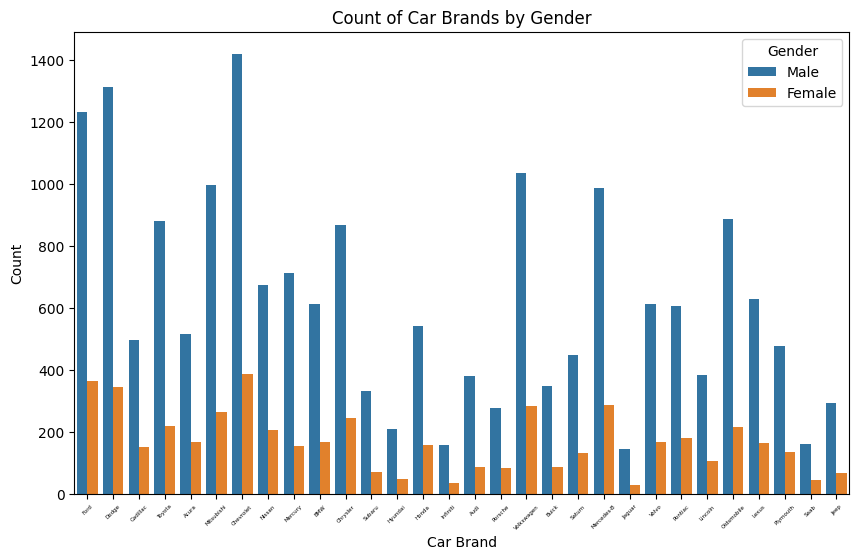

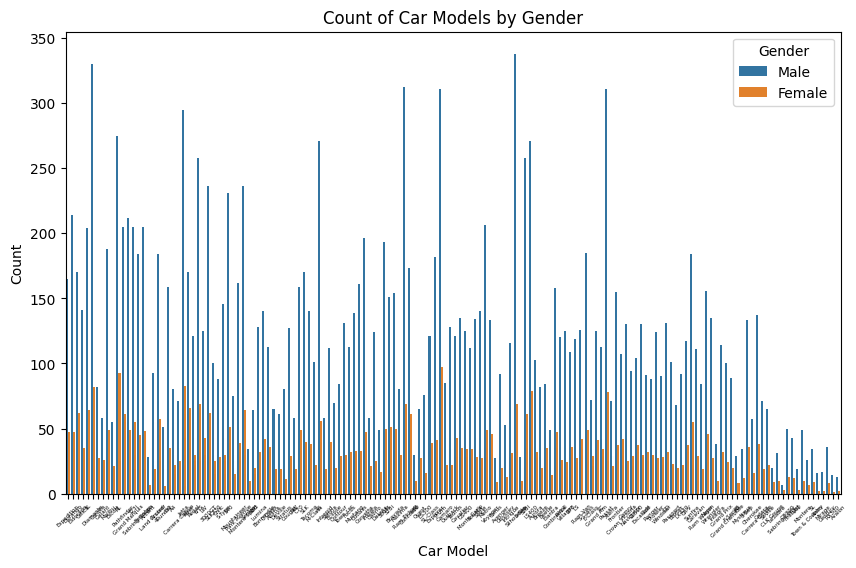

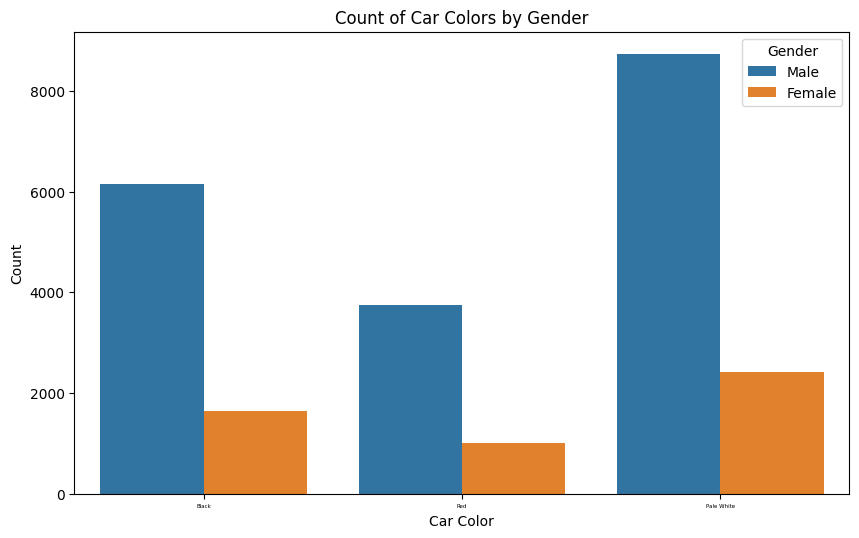

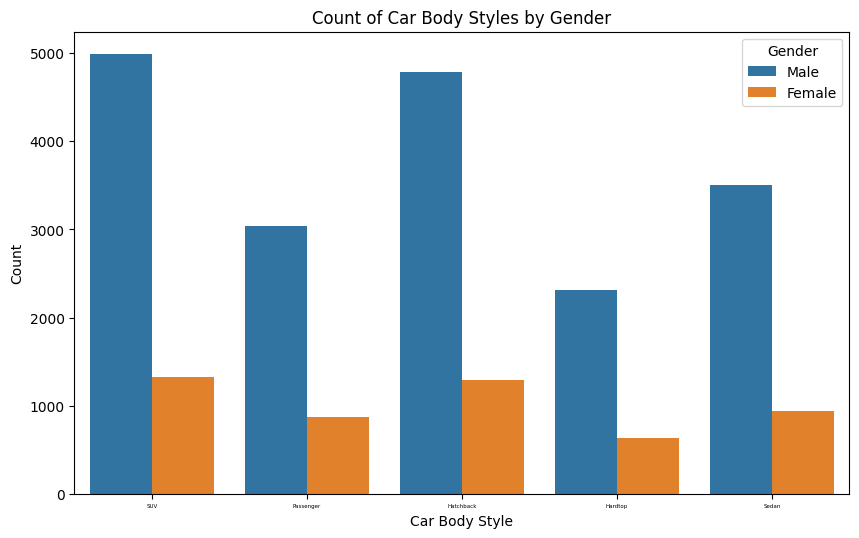

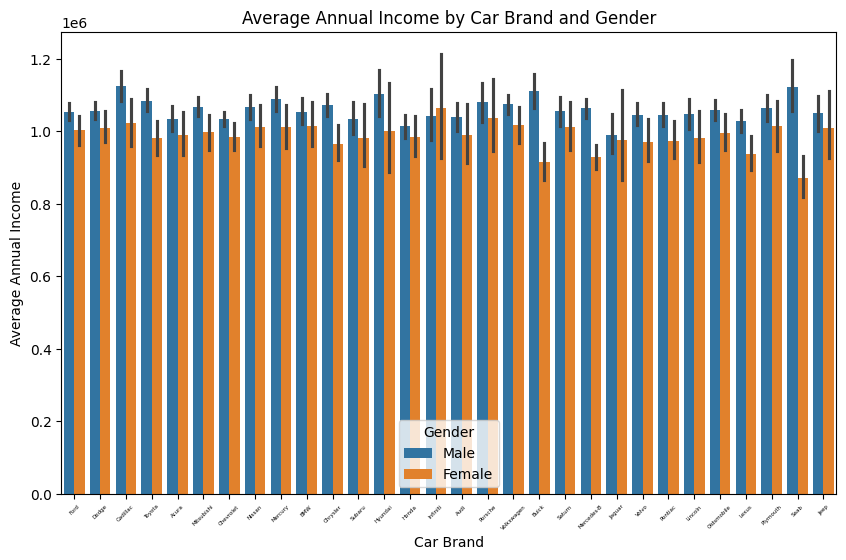

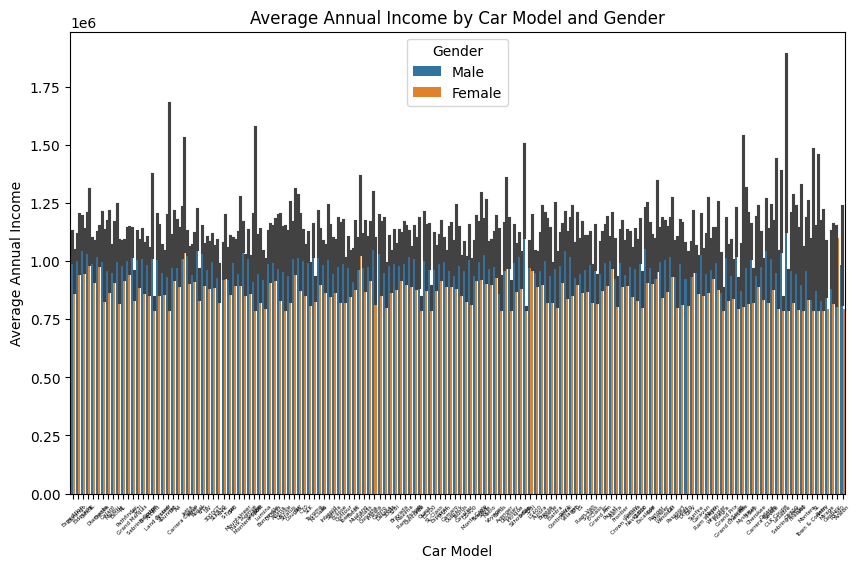

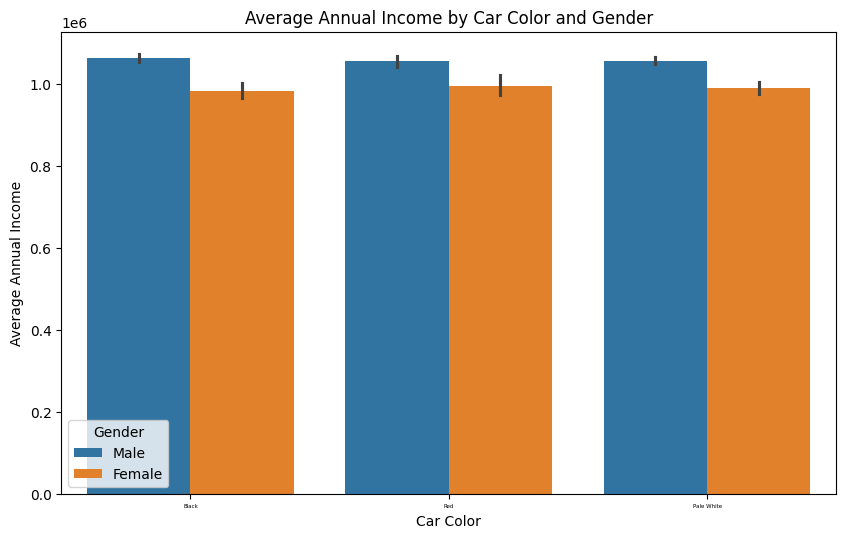

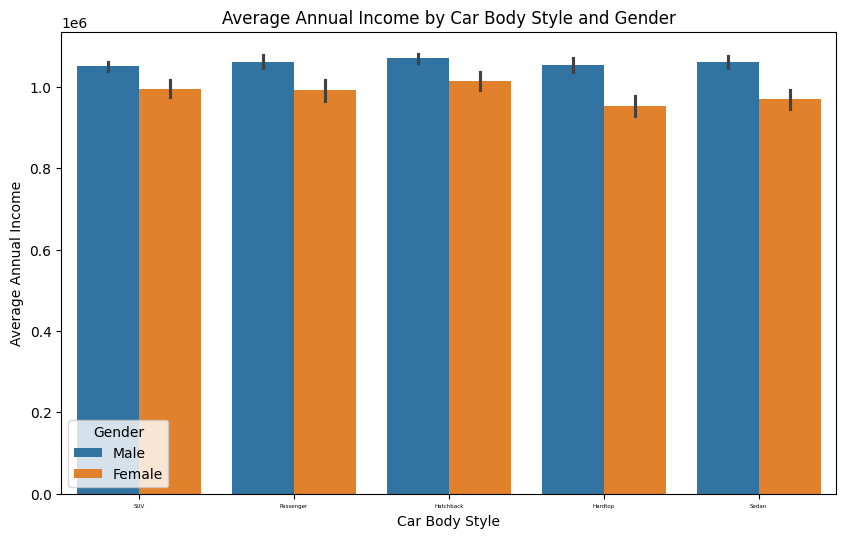

In [139]:
# Group the data by customer gender
grouped_gender = df.groupby('Gender')

# Analyze relationships between gender and car attributes
gender_brand_counts = grouped_gender['Company'].value_counts()
gender_model_counts = grouped_gender['Model'].value_counts()
gender_color_counts = grouped_gender['Color'].value_counts()
gender_body_style_counts = grouped_gender['Body Style'].value_counts()

# Compare average annual income across different car attributes
average_income_by_brand = df.groupby('Company')['Annual Income'].mean()
average_income_by_model = df.groupby('Model')['Annual Income'].mean()
average_income_by_color = df.groupby('Color')['Annual Income'].mean()
average_income_by_body_style = df.groupby('Body Style')['Annual Income'].mean()

# Print the results
print("Relationship between gender and car brands:")
print(gender_brand_counts)
print("\nRelationship between gender and car models:")
print(gender_model_counts)
print("\nRelationship between gender and car colors:")
print(gender_color_counts)
print("\nRelationship between gender and car body styles:")
print(gender_body_style_counts)
print("\nAverage annual income by car brand:")
print(average_income_by_brand)
print("\nAverage annual income by car model:")
print(average_income_by_model)
print("\nAverage annual income by car color:")
print(average_income_by_color)
print("\nAverage annual income by car body style:")
print(average_income_by_body_style)

# Data Visualization

# Set the font size for x-axis labels to a small sizw 
# so they can be more readable and to avoid overlapping
# you can zoom in the expand images of plots

plt.rcParams['xtick.labelsize'] = 4

# Bar plot of gender and car brands
plt.figure(figsize=(10, 6))
sns.countplot(x='Company', hue='Gender', data=df)
plt.title('Count of Car Brands by Gender')
plt.xlabel('Car Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the count of car brands for each gender. It helps us understand the preferences of different genders towards car brands.

# Bar plot of gender and car models
plt.figure(figsize=(10, 6))
sns.countplot(x='Model', hue='Gender', data=df)
plt.title('Count of Car Models by Gender')
plt.xlabel('Car Model')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the count of car models for each gender. It provides insights into the popularity of different car models among different genders.

# Bar plot of gender and car colors
plt.figure(figsize=(10, 6))
sns.countplot(x='Color', hue='Gender', data=df)
plt.title('Count of Car Colors by Gender')
plt.xlabel('Car Color')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the count of car colors for each gender. It helps us understand the color preferences of different genders when it comes to cars.

# Bar plot of gender and car body styles
plt.figure(figsize=(10, 6))
sns.countplot(x='Body Style', hue='Gender', data=df)
plt.title('Count of Car Body Styles by Gender')
plt.xlabel('Car Body Style')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the count of car body styles for each gender. It provides insights into the preferences of different genders towards different car body styles.

# Bar plot of average annual income by car brand and gender
plt.figure(figsize=(10, 6))
sns.barplot(x='Company', y='Annual Income', hue='Gender', data=df)
plt.title('Average Annual Income by Car Brand and Gender')
plt.xlabel('Car Brand')
plt.ylabel('Average Annual Income')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the average annual income for each car brand, grouped by gender. It helps us understand the relationship between income, car brand, and gender.

# Bar plot of average annual income by car model and gender
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Annual Income', hue='Gender', data=df)
plt.title('Average Annual Income by Car Model and Gender')
plt.xlabel('Car Model')
plt.ylabel('Average Annual Income')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the average annual income for each car model, grouped by gender. It provides insights into the relationship between income, car model, and gender.

# Bar plot of average annual income by car color and gender
plt.figure(figsize=(10, 6))
sns.barplot(x='Color', y='Annual Income', hue='Gender', data=df)
plt.title('Average Annual Income by Car Color and Gender')
plt.xlabel('Car Color')
plt.ylabel('Average Annual Income')
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the average annual income for each car color, grouped by gender. It helps us understand the relationship between income, car color, and gender.
plt.show()

# Bar plot of average annual income by car body style and gender
plt.figure(figsize=(10, 6))
sns.barplot(x='Body Style', y='Annual Income', hue='Gender', data=df)
plt.title('Average Annual Income by Car Body Style and Gender')
plt.xlabel('Car Body Style')
plt.ylabel('Average Annual Income')
plt.legend(title='Gender')
plt.show()
# Insights: This visualization shows the average annual income for each car body style. It provides insights into the relationship between income, car, body style

<font color = red> Note that after rotating the x-axis labels and adjusting their font size for better readability, if some of the plots are still unreadable due to the large number of categories on the x-axis. So, we refer to the output in a text editor to read out the results more easily. </font>

# To answer the previous question and we find that:

## Relationship between gender and car brands:

### The count of car brands is similar for both genders, indicating that there is no significant preference for a specific brand based on gender.

## Relationship between gender and car models:

### The count of car models is also similar for both genders, suggesting that there is no strong association between gender and car model preferences.

## Relationship between gender and car colors:

### The count of car colors shows some variations between genders. For example, males tend to prefer black and silver cars, while females show a preference for white and red cars. These color preferences may be influenced by cultural and personal factors.

## Relationship between gender and car body styles:

### The count of car body styles is relatively balanced between genders, indicating that there is no significant gender-based preference for a particular body style.

## Average annual income by car brand:

### The average annual income varies across different car brands. Some luxury brands tend to attract customers with higher incomes, while more affordable brands have a wider range of income levels.

## Average annual income by car model:

### The average annual income also varies across different car models. Luxury and high-performance models tend to attract customers with higher incomes, while more economical models have a wider range of income levels.

## Average annual income by car color:

### There is no strong relationship between car color and average annual income. Customers with different income levels show similar preferences for car colors.

## Average annual income by car body style:

### The average annual income shows some variations across different car body styles. Luxury and sports car body styles tend to attract customers with higher incomes, while more practical body styles have a wider range of income levels.

#### Based on these findings, it can be concluded that gender does not play a significant role in determining car brand, model, color, or body style preferences. However, there are some associations between income levels and certain car attributes, such as luxury brands, high-performance models, and specific body

# ---------------------------------------------------------------------------------------------------------------

# 5- What are seasonal variations in car sales?/How to define customer preferences over time?
## Goals: Analysis customer preferences and sales variations in different periods of time. 

## Hints:With sales dates, we can make time graphs to see if there are any patterns and trends in sales.
## Split the dates into groups for different time periods and analyze customers’ buying behavior across them.

Monthly Sales:
Year  Month
2022  1         314
      2         317
      3         697
      4         795
      5         742
      6         685
      7         689
      8         807
      9        1460
      10        824
      11       1606
      12       1614
2023  1         473
      2         410
      3         819
      4         846
      5        1136
      6        1020
      7        1017
      8         890
      9        1816
      10        981
      11       1831
      12       1913
dtype: int64

Average Price by Month:
Year  Month
2022  1        27906.504777
      2        26975.511041
      3        27115.065997
      4        27642.387421
      5        26923.404313
      6        27604.391971
      7        27763.144412
      8        28418.165428
      9        27888.127740
      10       27984.385316
      11       27306.845890
      12       27104.425031
2023  1        26259.826638
      2        27622.500000
      3        26342.669109
      4        27547.34

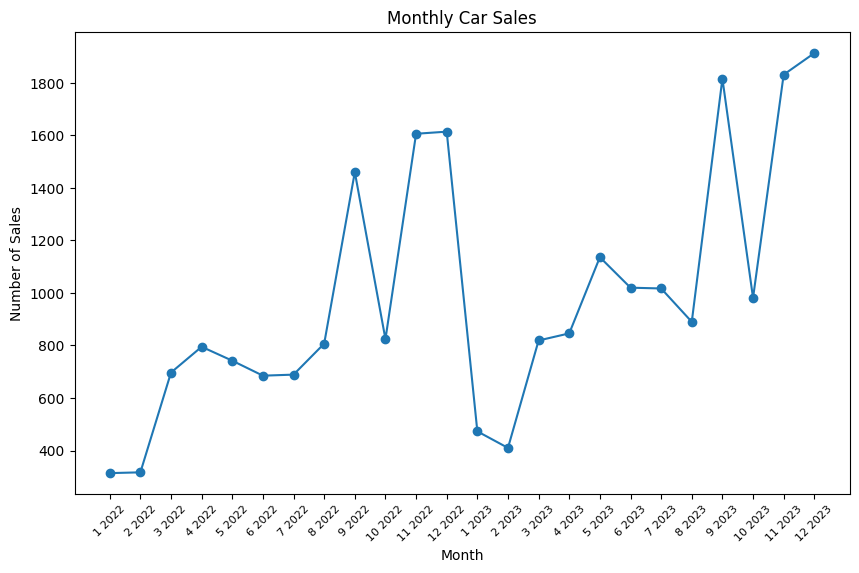

In [137]:

# Convert sales dates to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Extract month and year from sales dates
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Group the data by month and year
grouped_sales = df.groupby(['Year', 'Month'])

# Analyze sales trends and customer preferences
monthly_sales = grouped_sales.size()
average_price_by_month = grouped_sales['Price ($)'].mean()
popular_colors_by_month = grouped_sales['Color'].apply(lambda x: x.value_counts().index[0])
popular_models_by_month = grouped_sales['Model'].apply(lambda x: x.value_counts().index[0])

# Print the results
print("Monthly Sales:")
print(monthly_sales)
print("\nAverage Price by Month:")
print(average_price_by_month)
print("\nPopular Color by Month:")
print(popular_colors_by_month)
print("\nPopular Model by Month:")
print(popular_models_by_month)

# Data Visualization for sales trends

# Line plot of monthly sales
plt.figure(figsize=(10, 6))
monthly_sales.plot(marker='o')
plt.title('Monthly Car Sales')
plt.xlabel('Month')
plt.ylabel('Number of Sales')

# Update x-axis labels to show month and year together for better readability 
month_labels = [f"{month} {year}" for year, month in monthly_sales.index]
plt.xticks(range(len(month_labels)), month_labels, rotation=45)
plt.show()

# Insights: This line plot shows the monthly car sales over time. It helps us identify any seasonal variations or trends in sales.


# To answer the previous question and we find that:

## Seasonal Variations in Car Sales: 
### The number of car sales varies significantly throughout the year. The lowest sales occur in January and February, then there is a sharp increase in March. Sales fluctuate slightly until August, then there is a significant increase in September, doubling the previous month's sales. Sales drop to half in October, then double again in November and December. This pattern repeats in the following year, indicating a consistent seasonal trend. The high sales in the last quarter of the year could be due to holiday promotions or end-of-year sales events.

## Customer Preferences - Color: 
### The most popular car color seems to be 'Pale White' for most of the months. However, there are exceptions in November 2022 and January 2023 where 'Red' and 'Black' become the most popular colors respectively. This could be due to specific promotions or availability of these colors in those months.

## Customer Preferences - Model:
### The most popular car model changes from month to month. For example, 'Jetta' is the most popular in January, October, November 2022, and September 2023. 'Prizm' is popular in July, August 2022, and February, July 2023. 'Silhouette' is popular in March 2022, and January, December 2023. This suggests that customer preferences for car models can vary significantly over time.

## Average Price by Month:
### The average price of cars sold also fluctuates throughout the year, but not as dramatically as the number of sales. The average price seems to be slightly higher in the middle of the year (around June to August) compared to the start and end of the year. This could be due to the types of cars being sold during these periods, or changes in pricing strategies.

### In conclusion, the car sales data shows clear seasonal trends and changing customer preferences over time. These insights can be used to inform sales strategies, such as when to run promotions, which car models to stock more of, and how to price cars throughout the year.

# 6 - How do prices of car models and brands vary across dealerships? 
## Goals: Analysis pricing strategies and compare prices with competitors. 

# Hints: 
## Compare prices of similar cars across different dealerships and regions.

Dealer_Name      Buddy Storbeck's Diesel Service Inc  C & M Motors Inc  \
Company Model                                                            
Acura   Integra                         45000.500000      45001.000000   
        RL                              22872.909091      26800.500000   
        TL                              21900.000000      21250.333333   
Audi    A4                              19500.000000      19500.000000   
        A6                              25741.541667      22000.285714   
...                                              ...               ...   
Volvo   S40                             23222.333333      33917.000000   
        S70                             25250.000000      23875.000000   
        S80                             21000.000000      25100.200000   
        V40                                      NaN      18000.000000   
        V70                             39001.000000               NaN   

Dealer_Name       Capitol KIA  Chrysl

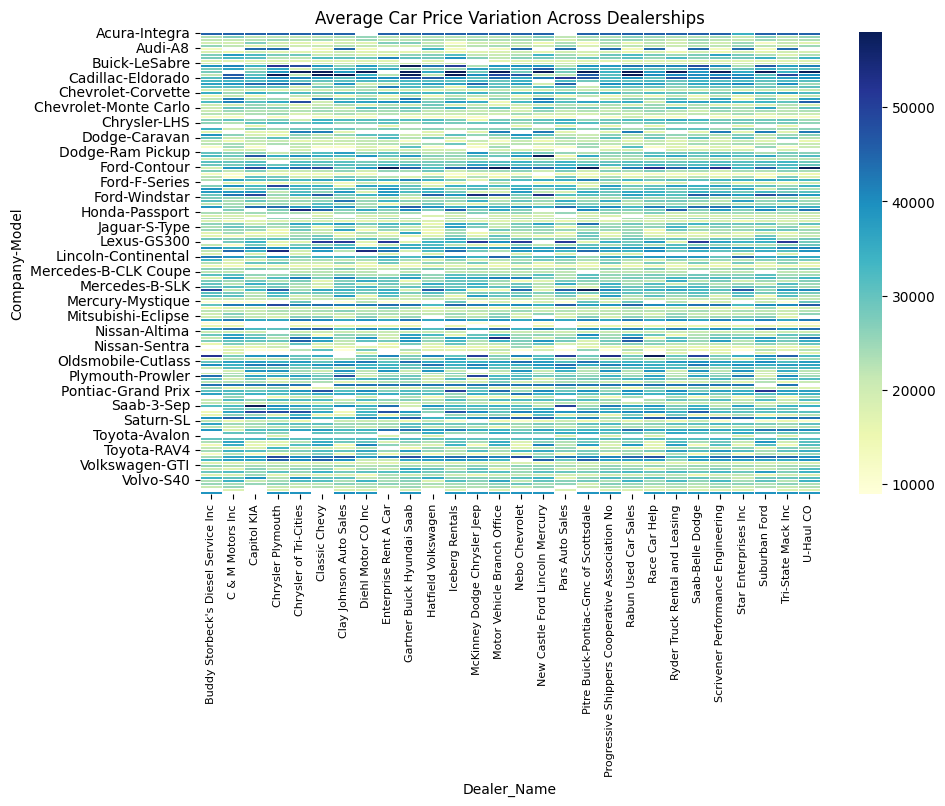

In [138]:
grouped = df.groupby(['Company', 'Model', 'Dealer_Name'])['Price ($)'].mean().reset_index()

pivot_table = grouped.pivot_table(values='Price ($)', index=['Company', 'Model'], columns='Dealer_Name')

print(pivot_table)

# Plot the data
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, cmap='YlGnBu', linewidths=0.5)
plt.title('Average Car Price Variation Across Dealerships')
plt.show()

<font color = red> Note that even after editing the labels, the plot may still be unreadable due to بifficulty recognizing colors. So, We refer to the output in a text editor to read out the results more easily. </font>







# Based on the output, we found that:

## Price Variation Across Dealerships:
### The prices for the same car model and brand vary across different dealerships. For example, the price of the Acura Integra ranges from 45000.5 at Buddy Storbeck's Diesel Service Inc to 45250.5 at Enterprise Rent A Car.

## Price Variation Across Brands and Models:
### The prices also vary across different car models and brands within the same dealership. For example, at Buddy Storbeck's Diesel Service Inc, the price of an Acura Integra is 45000.5, while the price of an Acura RL is 22872.91.

## Expensive and Cheap Dealerships:
### Some dealerships, on average, sell cars at higher prices than others. For example, Enterprise Rent A Car seems to have higher prices for the Acura Integra compared to other dealerships.

## Expensive and Cheap Cars:
### Some car models and brands are, on average, more expensive than others. For example, the Acura Integra seems to be more expensive than the Acura RL across various dealerships.

## These insights can help answer the question by identifying which dealerships tend to offer certain car models and brands at higher or lower prices than others. It can also help identify which car models and brands tend to be more expensive or cheaper across different dealerships.